# Visualize deep-MPN performance on example trials

Reload trained `dmpn` networks (one seed, each learning rule), generate held-out
trials, run the networks, and inspect performance — mirroring
MultiTaskMPN/one_task's example-trial figure:

- **top panel:** the input channels of one trial (fixation, stimulus, task cue).
- **bottom panel:** per output channel, the **target** (faded, thick) vs. the
  **network output** (solid). A well-trained net's output tracks the target.

Plus a held-out **angle-accuracy** summary per rule. Set `SEED` / `RULES` below to
match a completed `train_mpn.py` run (checkpoints assumed `dmpn`).

In [1]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt

import _bootstrap  # noqa: F401  -- prepends ../core + ../scripts to sys.path
import mpn_tasks
import train_mpn as tm      # ONLY for load_net / forward_outputs (checkpoint- & net-driven,
                            # they do not read train_mpn's module globals)

%matplotlib inline
plt.rcParams["figure.dpi"] = 110

# Rule display labels kept LOCAL so this notebook does not depend on train_mpn globals.
RULE_LABEL = {"bptt": "BPTT", "local_diag_rflo": "diagonal RFLO",
              "local_exact_rowlocal": "exact row-local", "local_direct": "direct"}

## 1. Choose the run to load (by checkpoint name)

In [2]:
# --- run selection: point directly at saved checkpoints ---
# CKPT_STEM is the checkpoint filename up to (and INCLUDING) the trailing "_" that
# precedes "{rule}_seed{SEED}.pt". Copy it straight from a saved checkpoint name, e.g.
#   dmpn_contextdelaydm1_h200-200_b128_n5000_lr1e-03_direct_fa_eta1.00_lam0.99_
# The per-rule file loaded for each rule is:
#   {CKPT_DIR}/{CKPT_STEM}{rule}_seed{SEED}.pt
# Nothing here is regenerated from train_mpn's globals — the net AND the task config
# come from the checkpoints themselves.
CKPT_DIR  = tm.CKPT_DIR    # default <root>/checkpoints; set to any path you like
CKPT_STEM = "dmpn_contextdelaydm1_h200-200_b128_n5000_lr1e-03_direct_fa_fbnorm_in-match_eta1.00_lam0.99_"
SEED      = 548787145             # the seed suffix on the checkpoint files
RULES     = ["bptt", "local_diag_rflo", "local_direct"]
DEVICE    = torch.device("cpu")

nets, ckpts = {}, {}
for rule in RULES:
    path = os.path.join(CKPT_DIR, f"{CKPT_STEM}{rule}_seed{SEED}.pt")
    ckpts[rule] = torch.load(path, map_location=DEVICE, weights_only=False)
    nets[rule]  = tm.load_net(path, device=DEVICE)   # rebuilds the net from ckpt net_params
    nets[rule].eval()
    print(f"{rule:20} <- {os.path.basename(path)}")

any_net = nets[RULES[0]]
any_ck  = ckpts[RULES[0]]
RULESET = any_ck.get("ruleset") or any_ck.get("net_params", {}).get("ruleset", "?")
print(f"\nruleset={RULESET}  n_input={any_net.n_input}  "
      f"n_hidden={any_net.n_hidden}  n_output={any_net.n_output}")

# --- Output folder for saved figures (created if missing) ---
# Figures from this notebook land in <root>/figure/notebooks/, named from the
# checkpoint stem + seed + a per-figure suffix, so they are self-describing and do
# not collide across runs. save_fig(fig, suffix) writes <stem><seed>_<suffix>.png.
import _bootstrap
FIG_OUT_DIR = _bootstrap.ROOT / "figure" / "notebooks"
FIG_OUT_DIR.mkdir(parents=True, exist_ok=True)   # create the intermediate folder

def save_fig(fig, suffix, dpi=150):
    """Save `fig` to FIG_OUT_DIR as <CKPT_STEM><SEED>_<suffix>.png and return the path."""
    fname = f"{CKPT_STEM}seed{SEED}_{suffix}.png"
    out = FIG_OUT_DIR / fname
    fig.savefig(out, dpi=dpi, bbox_inches="tight")
    print(f"saved figure -> {out}")
    return out

print(f"figures will be saved to: {FIG_OUT_DIR}")

import json as _json
def save_json(obj, suffix):
    """Save `obj` (JSON-serializable) to FIG_OUT_DIR as <CKPT_STEM>seed<SEED>_<suffix>.json
    and return the path. Same naming convention as save_fig, so a figure and its
    underlying numbers share a stem."""
    out = FIG_OUT_DIR / f"{CKPT_STEM}seed{SEED}_{suffix}.json"
    with open(out, "w") as fh:
        _json.dump(obj, fh, indent=2)
    print(f"saved json   -> {out}")
    return out

bptt                 <- dmpn_contextdelaydm1_h200-200_b128_n5000_lr1e-03_direct_fa_fbnorm_in-match_eta1.00_lam0.99_bptt_seed548787145.pt
local_diag_rflo      <- dmpn_contextdelaydm1_h200-200_b128_n5000_lr1e-03_direct_fa_fbnorm_in-match_eta1.00_lam0.99_local_diag_rflo_seed548787145.pt
local_direct         <- dmpn_contextdelaydm1_h200-200_b128_n5000_lr1e-03_direct_fa_fbnorm_in-match_eta1.00_lam0.99_local_direct_seed548787145.pt

ruleset=contextdelaydm1  n_input=6  n_hidden=200  n_output=3
figures will be saved to: /allen/programs/mindscope/workgroups/auto-model/zihan.zhang/mpn_local_learning/figure/notebooks


## 2. Generate held-out trials (from the checkpoint's own task params) and run each network

In [3]:
# Draw held-out trials from the checkpoint's OWN task params (saved at train time),
# so this notebook needs no matching train_mpn config. Older checkpoints that predate
# task_params storage fall back to tm.build_params() with a warning.
if "task_params" in any_ck:
    task_params  = any_ck["task_params"]     # already through convert_and_init (has rules/hp)
    net_params   = any_ck["net_params"]
else:
    print("WARNING: checkpoint has no stored task_params (old format) -- falling back to "
          "tm.build_params(); its config must match the trained run.")
    task_params, train_params, net_params = tm.build_params()
    task_params, train_params, net_params = mpn_tasks.convert_and_init_multitask_params(
        (task_params, train_params, net_params))
    net_params["prefs"] = mpn_tasks.get_prefs(task_params["hp"])

N_TRIALS = 500
np.random.seed(SEED); torch.manual_seed(SEED)
data, _ = mpn_tasks.generate_trials_wrap(
    task_params, N_TRIALS, rules=task_params["rules"],
    mode_input="random_batch", device=DEVICE)
inputs, labels, mask = (d.to(next(any_net.parameters()).dtype) for d in data)
inputs_np = inputs.cpu().numpy()
labels_np = labels.cpu().numpy()          # target output (B, T, n_output)

# Run every rule's net on the SAME trials.
outputs = {rule: tm.forward_outputs(net, inputs).cpu().numpy()
           for rule, net in nets.items()}
print(f"trials: inputs {inputs_np.shape}  target {labels_np.shape}")
print(f"task = {RULESET}  |  n_input={inputs_np.shape[-1]}  n_output={labels_np.shape[-1]}")

trials: inputs (500, 141, 6)  target (500, 141, 3)
task = contextdelaydm1  |  n_input=6  n_output=3


## 3. Accuracy per rule (ring-task angle accuracy)

accuracy device: cuda  |  forward minibatch: 32  |  modes: ['angle', 'stimulus']

Held-out angle accuracy on 500 trials  (task=contextdelaydm1, seed=548787145):
  BPTT               95.6%
  diagonal RFLO      11.3%
  direct             39.6%

Held-out stimulus accuracy on 500 trials  (task=contextdelaydm1, seed=548787145):
  BPTT               78.7%
  diagonal RFLO       0.0%
  direct             11.6%
saved json   -> /allen/programs/mindscope/workgroups/auto-model/zihan.zhang/mpn_local_learning/figure/notebooks/dmpn_contextdelaydm1_h200-200_b128_n5000_lr1e-03_direct_fa_fbnorm_in-match_eta1.00_lam0.99_seed548787145_accuracy_angle_stimulus.json
saved figure -> /allen/programs/mindscope/workgroups/auto-model/zihan.zhang/mpn_local_learning/figure/notebooks/dmpn_contextdelaydm1_h200-200_b128_n5000_lr1e-03_direct_fa_fbnorm_in-match_eta1.00_lam0.99_seed548787145_accuracy_angle_stimulus.png


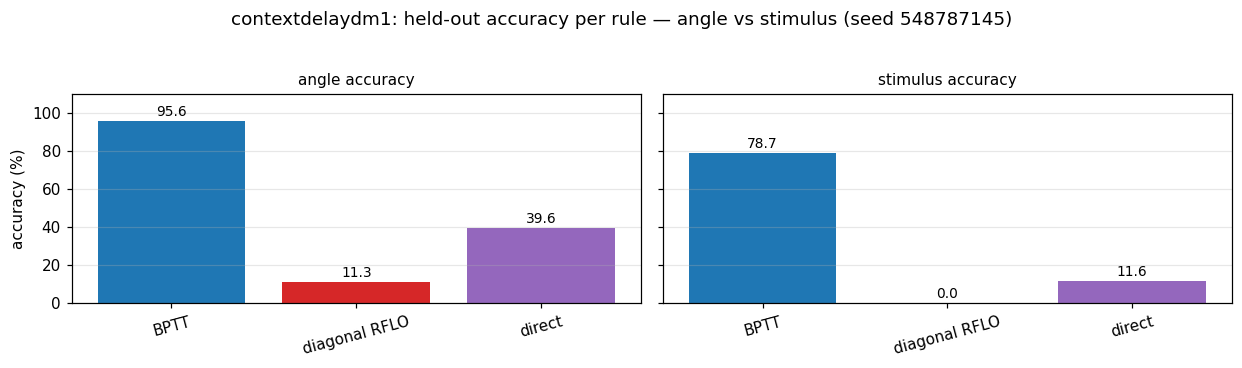

In [4]:
# Ring-task accuracy on the SAME held-out trials, for each rule, in BOTH scoring
# modes — "angle" (relative-position match, the training metric) AND "stimulus" (a
# stricter absolute-stimulus match). Computed on GPU when available, with the
# unrolled forward run in MINIBATCHES to bound peak memory (the per-timestep MP
# state M is the OOM risk, not the accuracy op). The forward is run ONCE per rule
# and scored in both modes. compute_acc returns a FRACTION in [0, 1]; ×100 → percent.
ACC_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ACC_BATCH  = 32          # forward minibatch (lower this if you still hit GPU OOM)
ACC_MODES  = ["angle", "stimulus"]
print(f"accuracy device: {ACC_DEVICE}  |  forward minibatch: {ACC_BATCH}  |  modes: {ACC_MODES}")


@torch.no_grad()
def forward_outputs_chunked(net, inputs, chunk, device):
    """Unrolled forward in batch-dim minibatches of `chunk` ON `device`, concatenated.
    Bounds peak memory (each chunk resets state with B=chunk, so chunking is exact up
    to float round-off — bit-exact in float64, ~1e-7 in float32). Returns (B,T,out)
    on `device`. The net is moved to `device` here and restored by the caller."""
    B = inputs.shape[0]
    outs = []
    for i in range(0, B, chunk):
        xb = inputs[i:i + chunk].to(device)
        outs.append(tm.forward_outputs(net, xb))
    return torch.cat(outs, dim=0)


# accs[mode][rule] = percent (0-100). Forward run once per rule, scored in both modes.
accs = {m: {} for m in ACC_MODES}
lab_d = labels.to(ACC_DEVICE)
msk_d = mask.to(ACC_DEVICE)
for rule, net in nets.items():
    orig_dev = next(net.parameters()).device          # restore afterwards (later cells use it)
    try:
        net.to(ACC_DEVICE)
        out_t = forward_outputs_chunked(net, inputs, ACC_BATCH, ACC_DEVICE)   # (B,T,out), once
        inp_d = inputs.to(ACC_DEVICE)
        for mode in ACC_MODES:
            try:
                acc, _ = net.compute_acc(out_t.float(), lab_d.float(), msk_d.float(),
                                         inp_d.float(), mode=mode, isvalid=True)
                accs[mode][rule] = 100.0 * float(acc)
            except Exception as e:
                accs[mode][rule] = float("nan")
                print(f"  {rule} [{mode}]: accuracy failed ({e})")
    finally:
        net.to(orig_dev)                               # leave nets as later cells expect
        if ACC_DEVICE.type == "cuda":
            torch.cuda.empty_cache()

for mode in ACC_MODES:
    print(f"\nHeld-out {mode} accuracy on {N_TRIALS} trials  (task={RULESET}, seed={SEED}):")
    for rule in RULES:
        print(f"  {RULE_LABEL.get(rule, rule):16} {accs[mode][rule]:6.1f}%")

# Persist the per-rule / per-mode accuracy (percent) + run metadata as JSON, so the
# numbers behind the bar chart are recoverable without re-running the notebook.
save_json({
    "ruleset": RULESET, "seed": int(SEED), "ckpt_stem": CKPT_STEM,
    "n_trials": int(N_TRIALS), "rules": list(RULES), "modes": list(ACC_MODES),
    "acc_percent": {m: {r: accs[m][r] for r in RULES} for m in ACC_MODES},
}, "accuracy_angle_stimulus")

# Bar charts: one panel per scoring mode (angle | stimulus), bars per rule.
_col = {"bptt": "#1f77b4", "local_diag_rflo": "#d62728",
        "local_direct": "#9467bd", "local_exact_rowlocal": "#2ca02c"}
xs = np.arange(len(RULES))
fig, axes = plt.subplots(1, len(ACC_MODES),
                         figsize=((1.4 * len(RULES) + 1.5) * len(ACC_MODES), 3.2),
                         squeeze=False, sharey=True)
for a, mode in enumerate(ACC_MODES):
    ax = axes[0][a]
    ax.bar(xs, [accs[mode][r] for r in RULES], color=[_col.get(r, "#888") for r in RULES])
    for x, r in zip(xs, RULES):
        v = accs[mode][r]
        if v == v:                                     # skip nan labels
            ax.text(x, v + 1, f"{v:.1f}", ha="center", va="bottom", fontsize=9)
    ax.set_xticks(xs); ax.set_xticklabels([RULE_LABEL.get(r, r) for r in RULES], rotation=15)
    ax.set_title(f"{mode} accuracy", fontsize=10)
    ax.set_ylim(0, 110); ax.grid(alpha=0.3, axis="y")
axes[0][0].set_ylabel("accuracy (%)")
fig.suptitle(f"{RULESET}: held-out accuracy per rule — angle vs stimulus (seed {SEED})",
             y=1.03, fontsize=12)
fig.tight_layout(); save_fig(fig, "accuracy_angle_stimulus")
plt.show()

## 4. Example-trial figure — input, target, and each rule's output

One column per example trial. Top row: input channels. Following rows: one per
learning rule, showing the **target** (faded thick line) vs. that rule's
**network output** (solid) for every output channel. Output tracking the target
= the network solves the trial.

saved figure -> /allen/programs/mindscope/workgroups/auto-model/zihan.zhang/mpn_local_learning/figure/notebooks/dmpn_contextdelaydm1_h200-200_b128_n5000_lr1e-03_direct_fa_fbnorm_in-match_eta1.00_lam0.99_seed548787145_example_trials.png


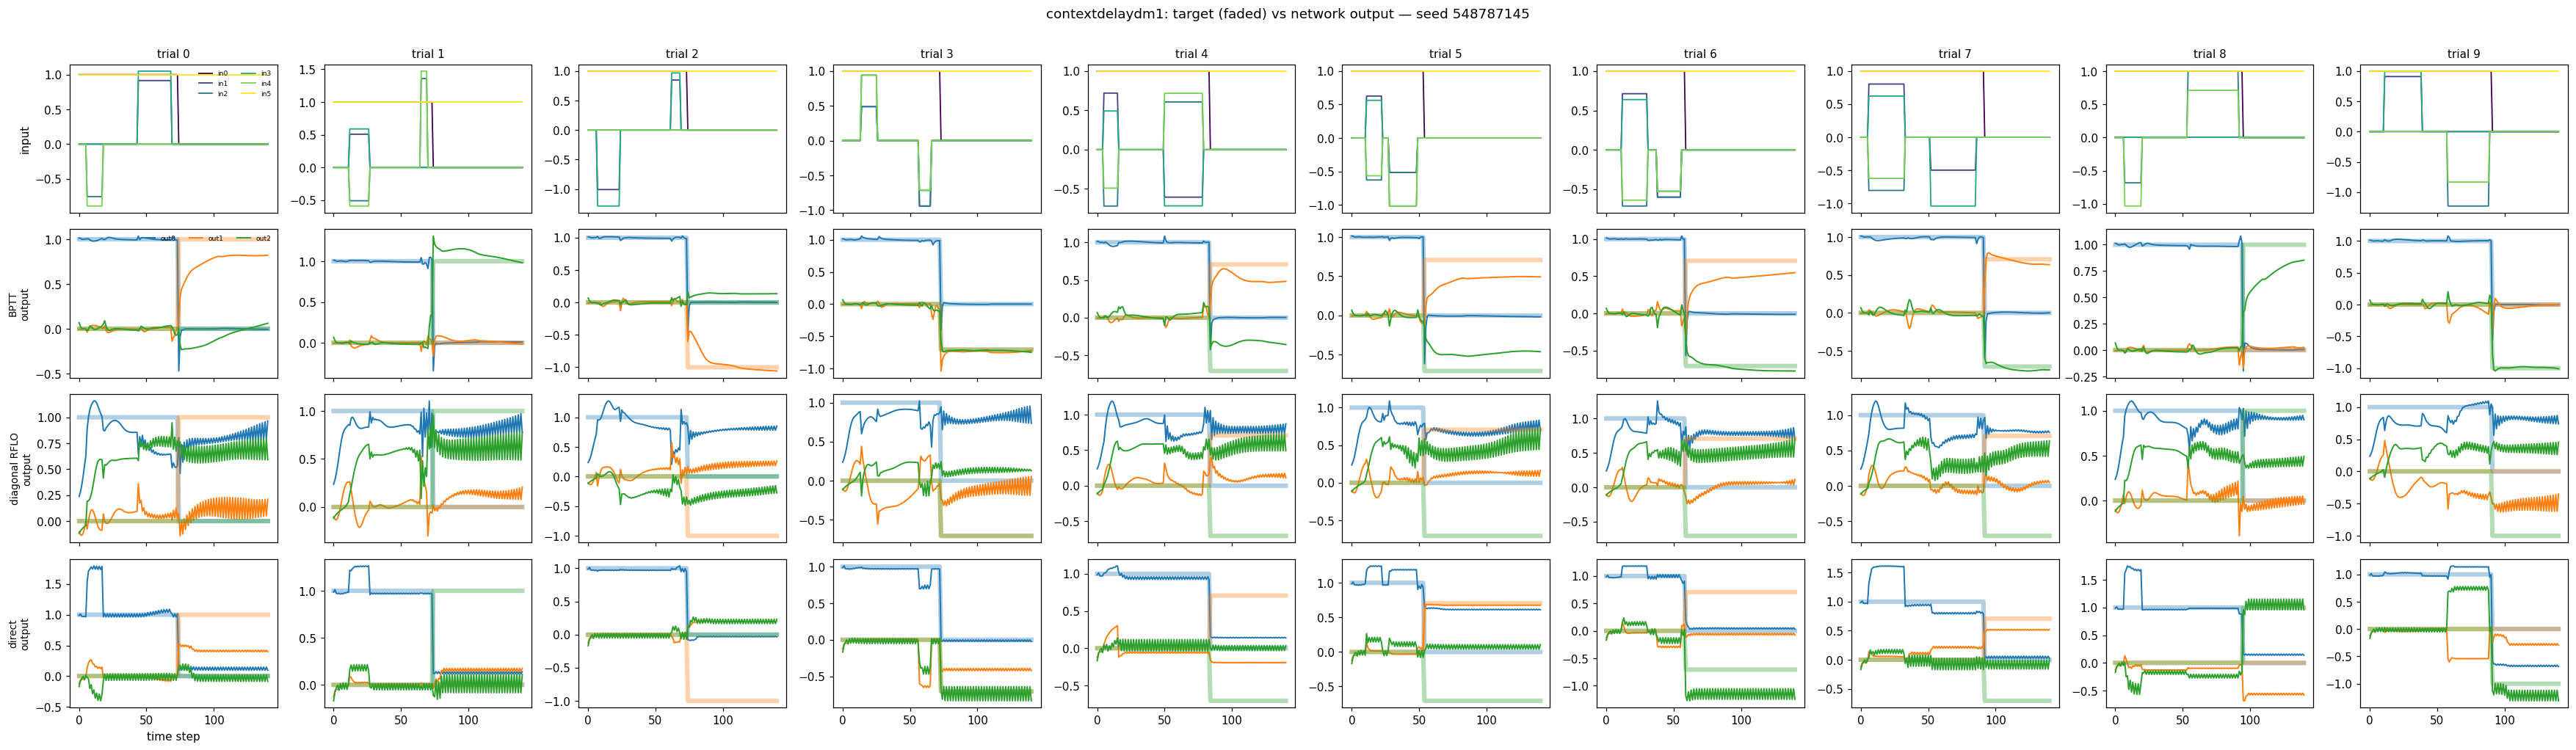

In [5]:
N_SHOW = min(10, N_TRIALS)              # example trials (columns) to display
n_out = labels_np.shape[-1]
n_in = inputs_np.shape[-1]

nrows = 1 + len(RULES)                 # input row + one row per rule
fig, axes = plt.subplots(nrows, N_SHOW, figsize=(3.2 * N_SHOW, 2.3 * nrows),
                         squeeze=False, sharex=True)
in_cmap = plt.cm.viridis(np.linspace(0, 1, n_in))
out_cmap = plt.cm.tab10(np.arange(n_out))

for c in range(N_SHOW):
    # Top: input channels for trial c.
    ax = axes[0][c]
    for ch in range(n_in):
        ax.plot(inputs_np[c, :, ch], color=in_cmap[ch], lw=1.2,
                label=f"in{ch}" if c == 0 else None)
    ax.set_title(f"trial {c}", fontsize=10)
    if c == 0:
        ax.set_ylabel("input", fontsize=10)
        ax.legend(fontsize=6, ncol=2, frameon=False, loc="upper right")

    # One row per rule: target (faded) vs network output (solid).
    for r, rule in enumerate(RULES):
        ax = axes[1 + r][c]
        for o in range(n_out):
            ax.plot(labels_np[c, :, o], color=out_cmap[o], lw=4, alpha=0.35)
            ax.plot(outputs[rule][c, :, o], color=out_cmap[o], lw=1.3,
                    label=f"out{o}" if c == 0 else None)
        if c == 0:
            ax.set_ylabel(f"{RULE_LABEL.get(rule, rule)}\noutput", fontsize=9)
            if r == 0:
                ax.legend(fontsize=6, ncol=n_out, frameon=False, loc="upper right")
axes[-1][0].set_xlabel("time step", fontsize=10)
fig.suptitle(f"{RULESET}: target (faded) vs network output — seed {SEED}",
             y=1.005, fontsize=12)
fig.tight_layout()
save_fig(fig, "example_trials")
plt.show()

## 5. Modulation (M) per synapse over time — one MP layer at a time

Roll out each rule's net on the SAME example trials and log the modulation matrix
M_t of every MP layer. For each layer M_t is (B, post, pre); we FLATTEN it to
post·pre synapses and plot each synapse's modulation trajectory across time — one
column per example trial, one row per (rule × MP layer). This is the M analog of
the example-trial output figure: it shows how the data-dependent plastic state that
the network actually computes with evolves over a trial, and how the local rules'
M-trajectories differ from BPTT's.

In [6]:
# Roll out every rule's net on the example trials, logging each MP layer's M_t.
# network_step runs the forward with M_{t-1} then updates M, so AFTER the call
# net.mp_layers[k].M is M_t. For a DEEP stack we only BUFFER (and later plot) the
# LAST few MP layers — capped by MAX_MP_LAYERS — to bound memory and figure size;
# the forward still runs through ALL layers (it must, for correct dynamics), we
# just skip storing M for the earlier ones. shown_layers holds the TRUE layer
# indices kept, so the plot labels them correctly (e.g. "MP L5" not "MP L0").
MAX_MP_LAYERS = 3                 # buffer/plot at most this many MP layers (the last ones)

n_layers = len(nets[RULES[0]].mp_layers)
shown_layers = list(range(n_layers))[-MAX_MP_LAYERS:]     # last <=MAX_MP_LAYERS indices
if len(shown_layers) < n_layers:
    print(f"{n_layers} MP layers present; buffering/plotting only the last "
          f"{len(shown_layers)} (indices {shown_layers}).")


@torch.no_grad()
def rollout_M(net, inputs, keep):
    """Roll the net over the trials; store M_t ONLY for the layer indices in `keep`
    (the forward still runs through every layer). Returns a list, parallel to
    `keep`, of arrays (B, T, post, pre)."""
    B, T, _ = inputs.shape
    net.reset_state(B=B)
    buf = [np.zeros((B, T) + tuple(net.mp_layers[k].M.shape[1:]), dtype=np.float32)
           for k in keep]
    for t in range(T):
        net.network_step(inputs[:, t, :], seq_idx=t)
        for j, k in enumerate(keep):
            buf[j][:, t] = net.mp_layers[k].M.cpu().numpy()   # M_t for TRUE layer k
    return buf

M_by_rule = {rule: rollout_M(net, inputs, shown_layers) for rule, net in nets.items()}
for rule in RULES:
    shapes = [m.shape for m in M_by_rule[rule]]
    print(f"{RULE_LABEL.get(rule, rule):16} M per shown layer: "
          + ", ".join(f"L{k}{s[2]}x{s[3]}={s[2]*s[3]} syn"
                      for k, s in zip(shown_layers, shapes)))

BPTT             M per shown layer: L0200x200=40000 syn, L1200x200=40000 syn
diagonal RFLO    M per shown layer: L0200x200=40000 syn, L1200x200=40000 syn
direct           M per shown layer: L0200x200=40000 syn, L1200x200=40000 syn


8 ring stimuli; 8 occupied → one trial each: stim0(θ=0.00)→trial421, stim1(θ=0.79)→trial345, stim2(θ=1.57)→trial260, stim3(θ=2.36)→trial95, stim4(θ=3.14)→trial175, stim5(θ=3.93)→trial30, stim6(θ=4.71)→trial43, stim7(θ=5.50)→trial14
saved figure -> /allen/programs/mindscope/workgroups/auto-model/zihan.zhang/mpn_local_learning/figure/notebooks/dmpn_contextdelaydm1_h200-200_b128_n5000_lr1e-03_direct_fa_fbnorm_in-match_eta1.00_lam0.99_seed548787145_modulation_per_synapse.png


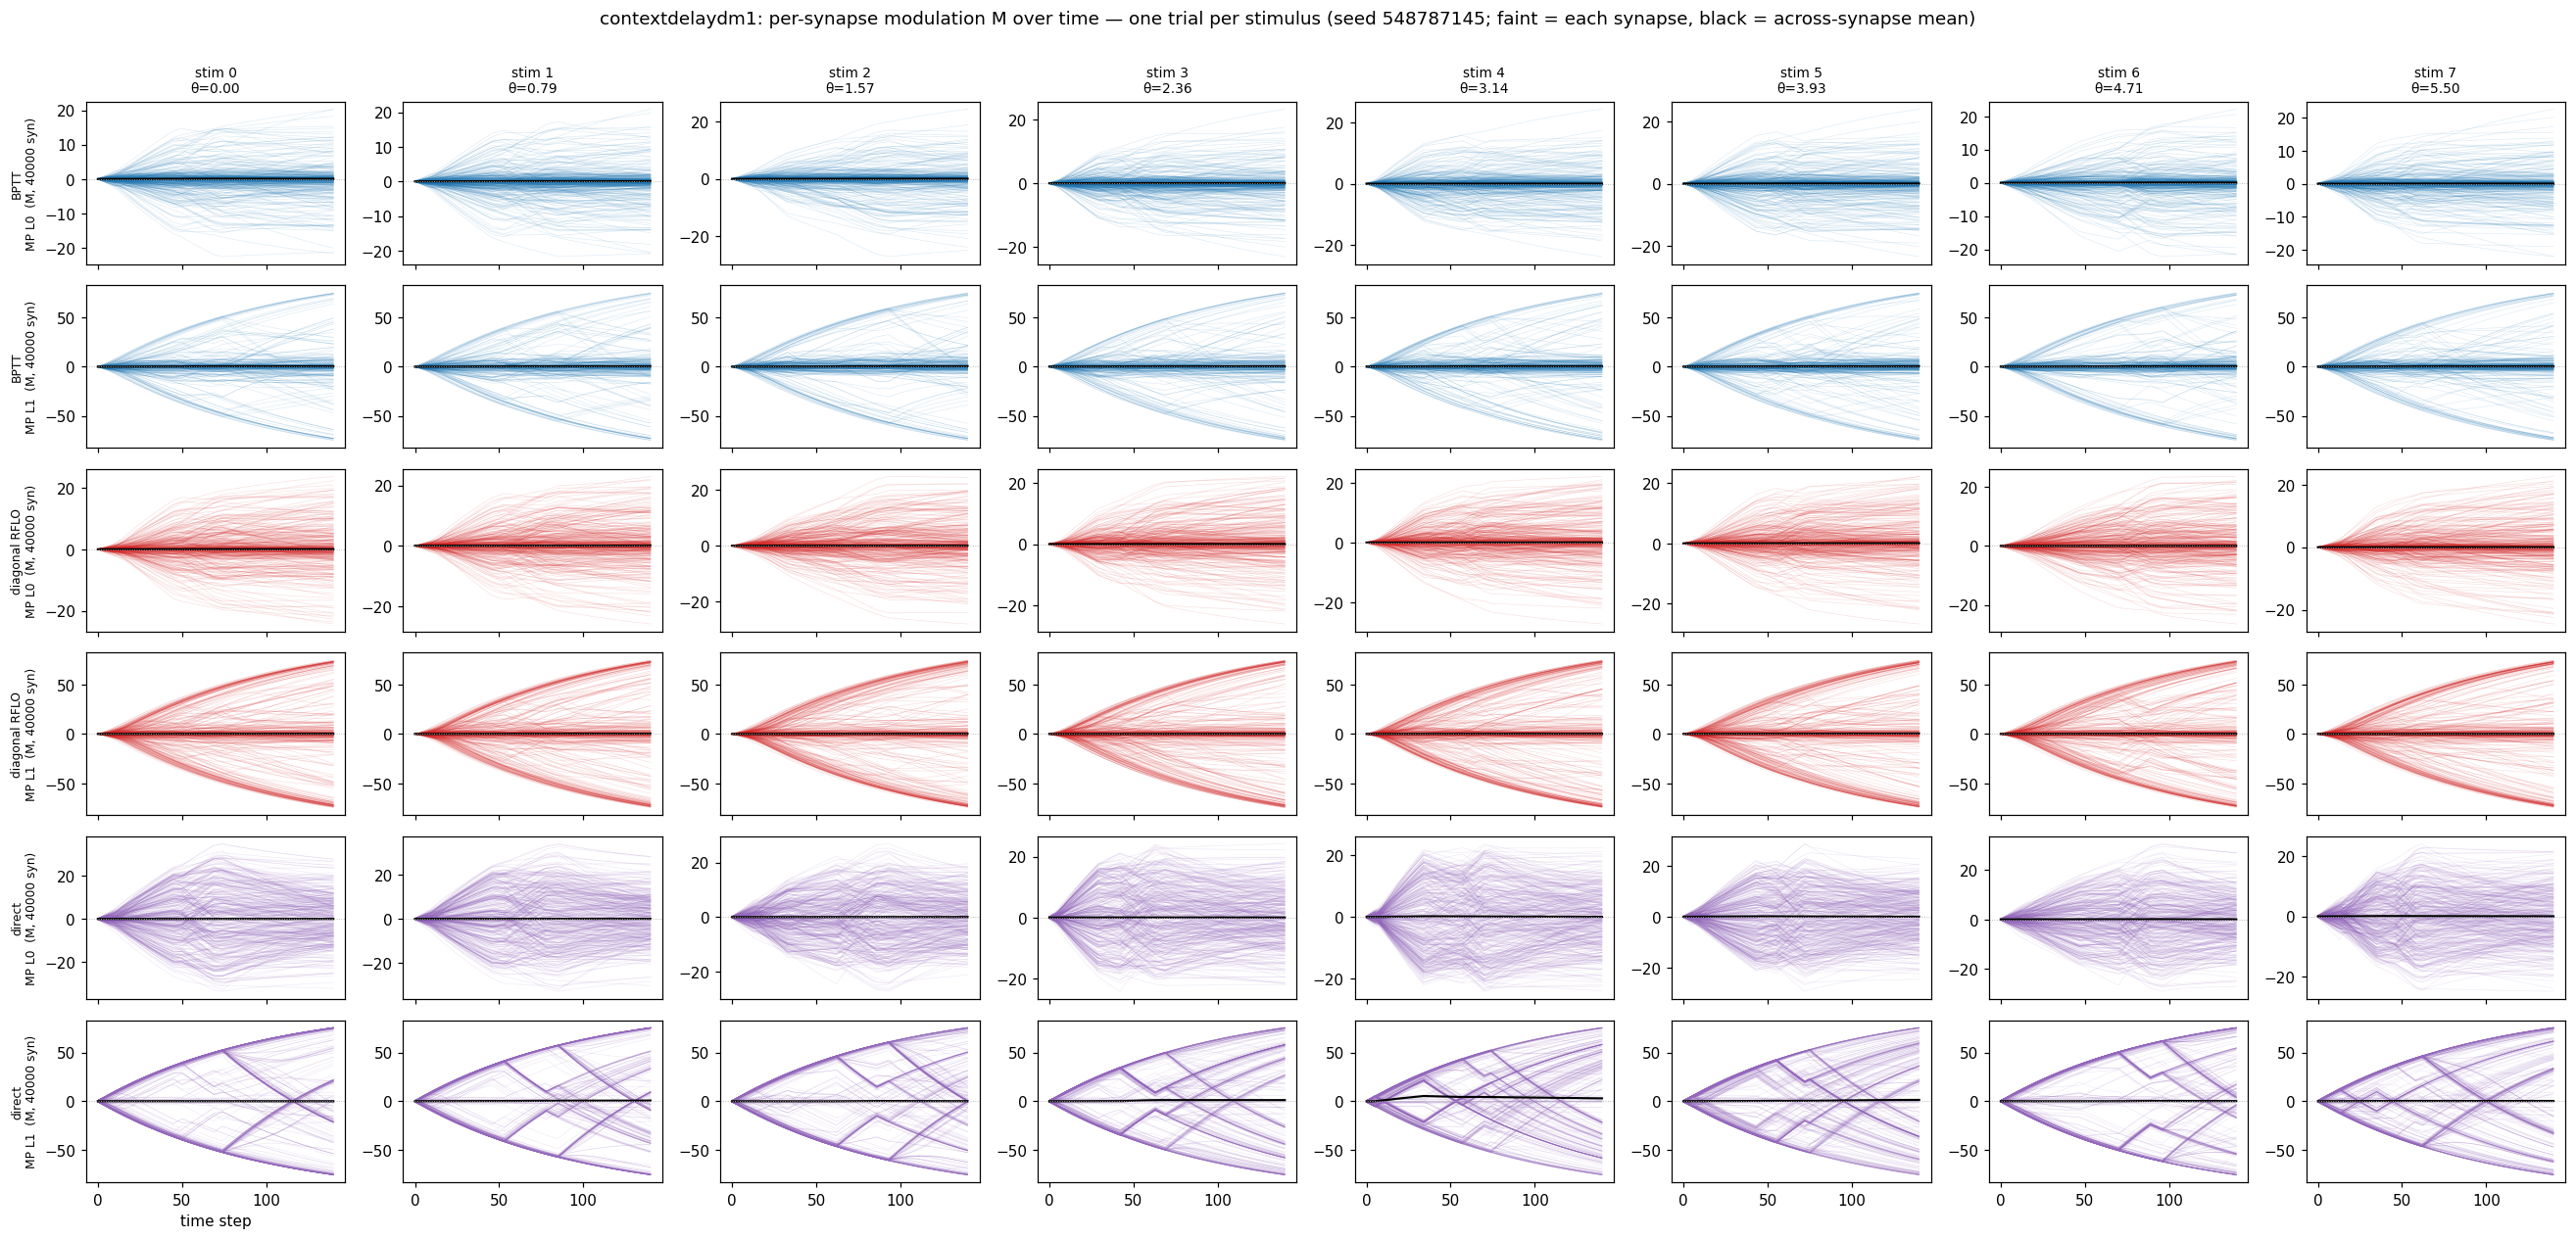

In [7]:
# Per-synapse M trajectories — ONE representative trial PER STIMULUS (so the number
# of columns = number of distinct ring stimuli, e.g. 8 for n_eachring=8, instead of
# all N_TRIALS). The ring-task stimulus is the RESPONSE-period target angle
# atan2(label_sin, label_cos), rounded to one of the n_eachring preferred directions
# (self.prefs) — exactly the classes net.compute_acc scores. We bin every trial by
# that angle and randomly pick one trial per occupied bin.
# Rows = (rule × MP layer); each faint line is one synapse M_ij(t), black = mean.
MAX_SYNAPSE = 400                 # cap lines drawn per panel (subsample if larger)
STIM_SEED   = 0                   # RNG for the one-trial-per-stimulus pick

# --- Preferred ring directions (the discrete stimuli) ---
prefs = np.asarray(any_net.prefs.detach().cpu().numpy() if hasattr(any_net, "prefs")
                   else task_params["hp"]["pref"])

# --- Per-trial stimulus bin from the response-period target (ch1=sin, ch2=cos) ---
def _stim_bin(b):
    m = mask_np[b, :, 0] > 0                     # scored (response) timesteps
    if m.sum() == 0:
        return -1
    sin = labels_np[b, m, 1].mean(); cos = labels_np[b, m, 2].mean()
    ang = np.mod(np.arctan2(sin, cos), 2 * np.pi)
    d = np.abs((prefs - ang + np.pi) % (2 * np.pi) - np.pi)   # periodic distance
    return int(np.argmin(d))

mask_np = mask.cpu().numpy()
stim_bins = np.array([_stim_bin(b) for b in range(inputs_np.shape[0])])
_rng = np.random.default_rng(STIM_SEED)
occupied = sorted(int(u) for u in np.unique(stim_bins) if u >= 0)
# one random trial index per occupied stimulus bin
picks = [(u, int(_rng.choice(np.where(stim_bins == u)[0]))) for u in occupied]
print(f"{len(prefs)} ring stimuli; {len(picks)} occupied → one trial each: "
      + ", ".join(f"stim{u}(θ={prefs[u]:.2f})→trial{b}" for u, b in picks))

ncols = len(picks)
# Rows iterate over the BUFFERED layers only (shown_layers, at most MAX_MP_LAYERS).
# `j` indexes M_by_rule[rule][j]; `k` is the corresponding TRUE MP-layer index.
rows = [(rule, j, k) for rule in RULES for j, k in enumerate(shown_layers)]
nrows = len(rows)
fig, axes = plt.subplots(nrows, ncols, figsize=(3.0 * ncols, 1.9 * nrows),
                         squeeze=False, sharex=True)
rng = np.random.default_rng(0)
for r, (rule, j, k) in enumerate(rows):
    M_seq = M_by_rule[rule][j]                       # (B, T, post, pre); j → buffered slot
    B, T, post, pre = M_seq.shape
    n_syn = post * pre
    flat = M_seq.reshape(B, T, n_syn)                # flatten synapses
    sel = (rng.choice(n_syn, MAX_SYNAPSE, replace=False) if n_syn > MAX_SYNAPSE
           else np.arange(n_syn))
    c = {"bptt": "#1f77b4", "local_diag_rflo": "#d62728",
         "local_direct": "#9467bd", "local_exact_rowlocal": "#2ca02c"}.get(rule, "#888")
    for col, (u, b) in enumerate(picks):
        ax = axes[r][col]
        traj = flat[b]                               # (T, n_syn) for the chosen trial
        ax.plot(traj[:, sel], color=c, lw=0.4, alpha=0.15)
        ax.plot(traj.mean(axis=1), color="k", lw=1.4)   # across-synapse mean
        ax.axhline(0.0, color="0.7", lw=0.6, ls=":")
        if r == 0:
            ax.set_title(f"stim {u}\nθ={prefs[u]:.2f}", fontsize=9)
        if col == 0:
            ax.set_ylabel(f"{RULE_LABEL.get(rule, rule)}\nMP L{k}  (M, {n_syn} syn)",
                          fontsize=8)   # k = true layer index
axes[-1][0].set_xlabel("time step", fontsize=10)
fig.suptitle(f"{RULESET}: per-synapse modulation M over time — one trial per stimulus "
             f"(seed {SEED}; faint = each synapse, black = across-synapse mean)",
             y=1.005, fontsize=12)
fig.tight_layout()
save_fig(fig, "modulation_per_synapse")
plt.show()